In [1]:
import sys, re, json
sys.path.append('..') 

from scripts.constants import *
from scripts.utils import *
from scripts.sedona_config import *

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
project_crs = 'EPSG:27700'

T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
T30_dir = T3_30_300_DIR / "T30"
T300_dir = T3_30_300_DIR / "T300"
t3_30_300_path = T3_30_300_DIR / "T3_30_300.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

In [3]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path)
imd_lsoa_bua_gdf = imd_lsoa_bua_gdf.sort_values(by='RGN22CD').drop_duplicates(subset='LSOA11CD', keep='first')
geo_level_codes = imd_lsoa_bua_gdf[geo_level].unique()
imd_england_columns = ['lsoa11cd', 'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop',
                       'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IncScore', 'IncRank', 'IncDec', 
                       'EmpScore', 'EmpRank', 'EmpDec', 'EduScore', 'EduRank', 'EduDec', 
                       'HDDScore', 'HDDRank', 'HDDDec', 'CriScore', 'CriRank', 'CriDec', 
                       'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore', 'EnvRank', 'EnvDec']
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns]

In [4]:
os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

25/03/13 09:32:02 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/03/13 09:32:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-573c3ba4-6ca9-4bb2-9671-3f0e92fa9bf2;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in central
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [5]:
boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
boundaries_sdf.createOrReplaceTempView('boundaries')
imd_england_sdf = sedona.createDataFrame(imd_england_gdf)
imd_england_sdf.createOrReplaceTempView('imd_england')
buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_sdf.createOrReplaceTempView("buildings")

In [6]:
t3_sdf = sedona.read.csv(str(T3_dir), header=True, inferSchema=True)
t3_sdf.createOrReplaceTempView("t3")
t30_sdf = sedona.read.csv(str(T30_dir), header=True, inferSchema=True)
t30_sdf.createOrReplaceTempView("t30")
t300_sdf = sedona.read.csv(str(T300_dir), header=True, inferSchema=True)
t300_sdf.createOrReplaceTempView("t300")

In [42]:
# Perform spatial join
buildings_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, l.LSOA11CD
    FROM buildings b
    JOIN boundaries l
    ON ST_Contains(l.geometry, b.geometry)
    """
)
buildings_lsoa_sdf.createOrReplaceTempView("buildings")

In [43]:
t30_imd_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, ROUND(ST_Area(b.geometry), 2) AS area, i.TotPop, i.DepChi, i.Pop16_59, i.`Pop60+`, i.WorkPop, 
           i.IMD_Rank, i.IMD_Decile, i.IMDScore, i.IncScore, i.IncRank, i.IncDec, i.EmpScore, i.EmpRank, 
           i.EmpDec, i.EduScore, i.EduRank, i.EduDec, i.HDDScore, i.HDDRank, i.HDDDec, i.CriScore, 
           i.CriRank, i.CriDec, i.BHSScore, i.BHSRank, i.BHSDec, i.EnvScore, i.EnvRank, i.EnvDec, 
           t.canopy_cover
    FROM boundaries b
    LEFT JOIN imd_england i ON b.LSOA11CD = i.lsoa11cd
    LEFT JOIN t30 t ON b.LSOA11CD = t.LSOA11CD
    """
)
t30_imd_lsoa_sdf.createOrReplaceTempView("t30_imd_lsoa")
t30_imd_lsoa_sdf.show()

+---------+--------------------+---------+--------------------+---------+----------------+---------+----------+---------+----------+--------------------+----------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+
| LSOA11CD|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|         LAD22NM|  BUA22CD|   BUA22NM|  RGN22CD|   RGN22NM|            geometry|      area|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|
+---------+--------------------+---------+--------------------+---------+----------------+---------+----------+---------+----------+--------------------+----------+------+---

In [44]:
t3_300_building_sdf = sedona.sql(
    """
    SELECT b.*, t3.tree_count, t300.closest_park_access_id, t300.distance
    FROM buildings b
    LEFT JOIN t3 ON b.verisk_premise_id = t3.verisk_premise_id
    LEFT JOIN t300 ON b.verisk_premise_id = t300.verisk_premise_id
    """
)
t3_300_building_sdf.createOrReplaceTempView("t3_300_building")
t3_300_building_sdf.show()

24/12/16 14:03:25 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+-------------+-----------------+--------------+------+---------------+-----------+-------------------+--------------------+-----------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|building_area|distance_building|distance_water|height| map_simple_use|    map_use|premise_floor_count|        premise_type|premise_use|premise_year|verisk_building_id|verisk_premise_id|            geometry| LSOA11CD|tree_count|closest_park_access_id|distance|
+-------------+-----------------+--------------+------+---------------+-----------+-------------------+--------------------+-----------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|        124.2|              6.1|         876.7|   5.4|    Residential|Residential|                  1|            Detached|Residential|        NULL|          43065385|          1396822|POLYGON ((531361....|E01013086|

In [45]:
t3_300_lsoa_sdf = sedona.sql(
    """
    SELECT LSOA11CD, ROUND(AVG(tree_count), 2) as tree_count, ROUND(AVG(distance), 2) as park_distance
    FROM t3_300_building
    GROUP BY LSOA11CD
    """
)

t3_300_lsoa_sdf.createOrReplaceTempView("t3_300_lsoa")
t3_300_lsoa_sdf.show()

24/12/16 14:04:43 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+---------+----------+-------------+
| LSOA11CD|tree_count|park_distance|
+---------+----------+-------------+
|E01029873|      NULL|      2141.94|
|E01026615|      NULL|      1981.59|
|E01026048|      NULL|     Infinity|
|E01022207|      NULL|      6844.61|
|E01023494|      NULL|      3440.36|
|E01031876|      NULL|      3456.38|
|E01027281|      NULL|       655.67|
|E01027633|      NULL|      6460.16|
|E01027571|      NULL|      4335.07|
|E01012927|     30.59|      1130.55|
|E01031630|      NULL|       399.14|
|E01019498|      NULL|       337.37|
|E01017869|     10.12|      1743.83|
|E01012567|     202.8|        472.8|
|E01031518|      NULL|     Infinity|
|E01020314|      NULL|     Infinity|
|E01028794|      NULL|      3429.28|
|E01019607|     29.64|      3936.35|
|E01024347|      NULL|      2844.73|
|E01013256|      NULL|       447.94|
+---------+----------+-------------+
only showing top 20 rows



In [11]:
t3_30_300_sdf = t30_imd_lsoa_sdf.join(t3_300_lsoa_sdf, on="LSOA11CD", how="inner")
t3_30_300_sdf = t3_30_300_sdf.drop("lsoa11cd")
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf = sedona.sql(
    """
    SELECT *, (TotPop / area) AS TotPop_density,
    (DepChi / TotPop) AS DepChi_ratio,
    (Pop16_59 / TotPop) AS Pop16_59_ratio,
    (`Pop60+` / TotPop) AS Pop60_ratio,
    (WorkPop / TotPop) AS WorkPop_ratio
    FROM t3_30_300
    
    """
    )
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf.show()

24/12/16 13:10:27 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------+---------------+--------------------+---------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+----------+-------------+--------------------+-------------------+------------------+-------------------+------------------+
|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|             LAD22NM|  BUA22CD|             BUA22NM|  RGN22CD|        RGN22NM|            geometry|     area|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|tree_count|park_distance|      TotP

In [46]:
t3_30_300_building_df = sedona.sql(
    """
    SELECT t3_300.map_use, t3_300.building_area, t3_300.height, t3_300.distance_water,
    t3_300.premise_floor_count, t3_300.premise_type, t3_300.premise_year,
    t30.IMDScore, t30.IMD_Decile, t30.IncScore, t30.EmpScore, 
    t30.EduScore, t30.HDDScore, t30.CriScore, t30.BHSScore, t30.EnvScore,
    t3_300.tree_count, t3_300.closest_park_access_id, t3_300.distance, t30.canopy_cover
    FROM t3_300_building t3_300
    LEFT JOIN t30_imd_lsoa t30 ON t3_300.LSOA11CD = t30.LSOA11CD
    """
)
t3_30_300_building_df = t3_30_300_building_df.filter(t3_30_300_building_df.canopy_cover.isNotNull())
t3_30_300_building_df.createOrReplaceTempView("t3_30_300_building")
t3_30_300_building_df.show()

24/12/16 14:08:18 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+-----------+-------------+------+--------------+-------------------+--------------------+------------+--------+----------+--------+--------+--------+--------+--------+--------+--------+----------+----------------------+--------+------------+
|    map_use|building_area|height|distance_water|premise_floor_count|        premise_type|premise_year|IMDScore|IMD_Decile|IncScore|EmpScore|EduScore|HDDScore|CriScore|BHSScore|EnvScore|tree_count|closest_park_access_id|distance|canopy_cover|
+-----------+-------------+------+--------------+-------------------+--------------------+------------+--------+----------+--------+--------+--------+--------+--------+--------+--------+----------+----------------------+--------+------------+
|Residential|          5.0|   3.0|         692.6|                  1|Domestic outbuilding|        NULL|  35.033|         2|   0.228|   0.128|  33.668|   0.035|   0.467|  44.311|  33.091|        33|  C198C36B-0BA6-46D...|   416.0|        3.12|
|Residential|        271.1| 

In [47]:
samp_size = 0.2
t3_30_300_building_sample_df = t3_30_300_building_df.sample(False, samp_size).toPandas()
t3_30_300_building_sample_df['park_distance'] = t3_30_300_building_sample_df['distance'].astype(float)

24/12/16 14:11:37 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


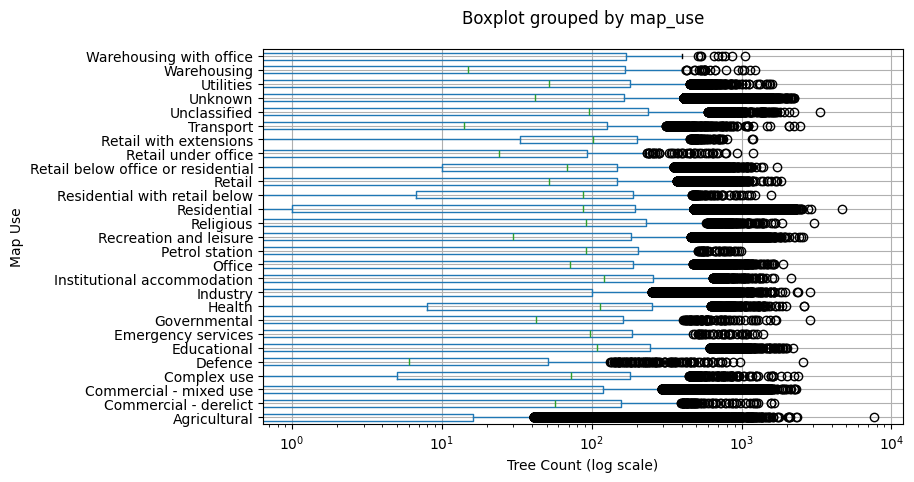

In [52]:
# Plot the boxplot with continuous variables on the x-axis in log scale
t3_30_300_building_sample_df.boxplot(column='tree_count', by='map_use', vert=False, figsize=(8, 5))
plt.xlabel('Tree Count (log scale)')
plt.ylabel('Map Use')
plt.xscale("log")
plt.title(None)
plt.show()

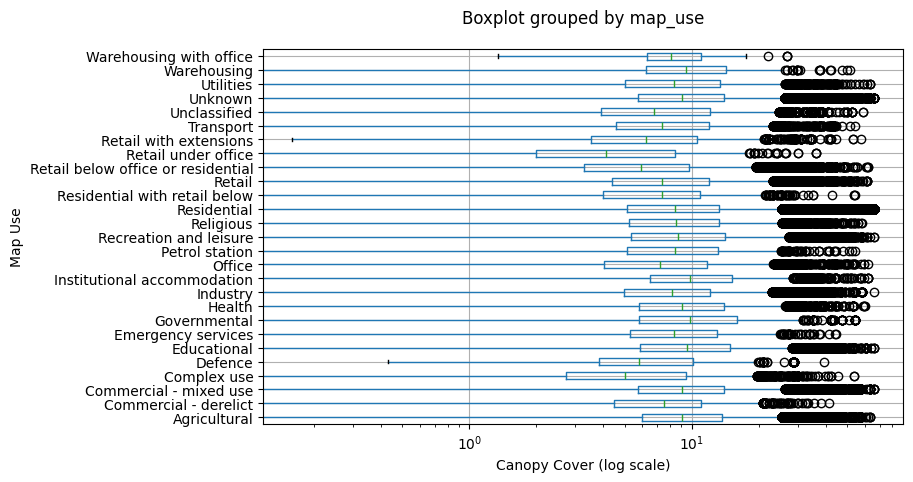

In [58]:
# Plot the boxplot with continuous variables on the x-axis in log scale
t3_30_300_building_sample_df.boxplot(column='canopy_cover', by='map_use', vert=False, figsize=(8, 5))
plt.xlabel('Canopy Cover (log scale)')
plt.ylabel('Map Use')
plt.xscale("log")
plt.title(None)
plt.show()

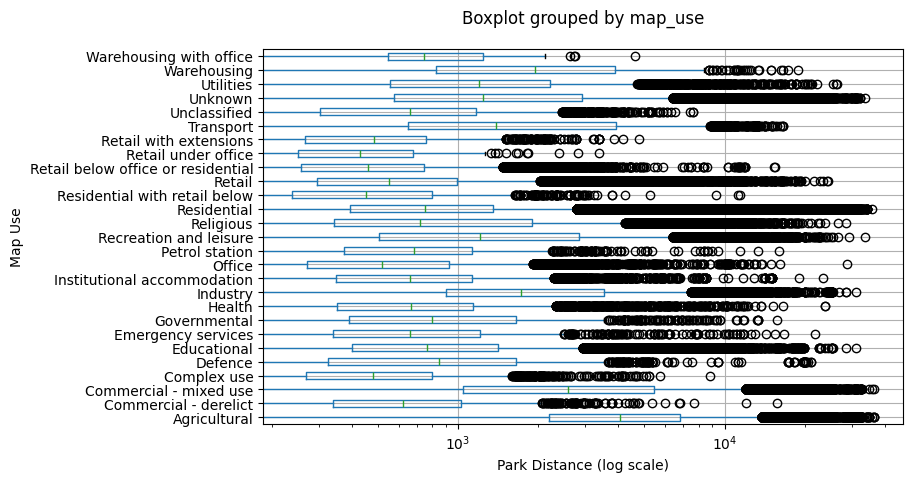

In [65]:
# Plot the boxplot with continuous variables on the x-axis in log scale
t3_30_300_building_sample_df.boxplot(column='park_distance', by='map_use', vert=False, figsize=(8, 5))
plt.xlabel('Park Distance (log scale)')
plt.ylabel('Map Use')
plt.xscale("log")
plt.title(None)
plt.show()

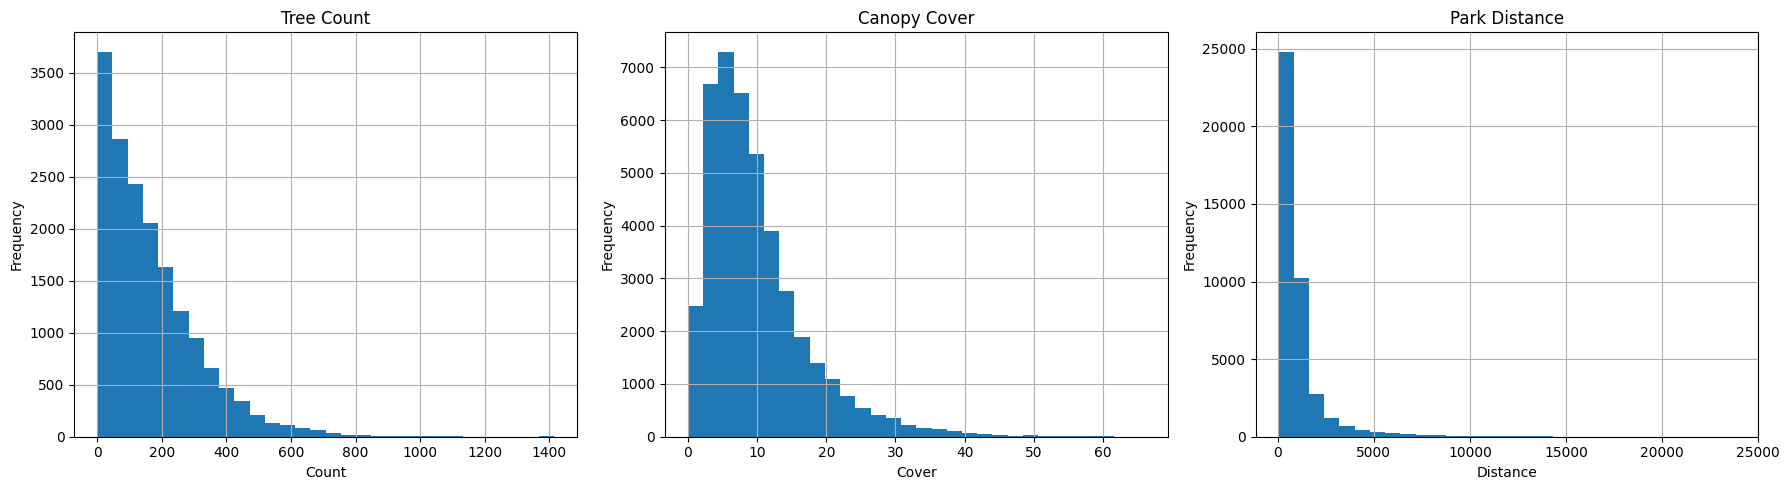

In [30]:
# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t3_30_300_df['tree_count'].hist(ax=axes[0], bins=30)
axes[0].set_title('Tree Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

t3_30_300_df['canopy_cover'].hist(ax=axes[1], bins=30)
axes[1].set_title('Canopy Cover')
axes[1].set_xlabel('Cover')
axes[1].set_ylabel('Frequency')

t3_30_300_df['park_distance'].hist(ax=axes[2], bins=30)
axes[2].set_title('Park Distance')
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [5]:
def create_schemas(sedona, imd_lsoa_bua_gdf, imd_england_gdf, spectral_indexes_gdf, buildings_path, T3_dir, T30_dir, T300_dir) -> None:

    # logging.debug("Creating schemas")

    boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
    boundaries_sdf.createOrReplaceTempView('boundaries')
    imd_england_sdf = sedona.createDataFrame(imd_england_gdf)
    imd_england_sdf.createOrReplaceTempView('imd_england')
    buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
    buildings_sdf.createOrReplaceTempView("buildings")
    spectral_indexes_sdf = sedona.createDataFrame(spectral_indexes_gdf)
    spectral_indexes_sdf.createOrReplaceTempView("spectral_indexes")

    t3_sdf = sedona.read.csv(str(T3_dir), header=True, inferSchema=True)
    t3_sdf.createOrReplaceTempView("t3")
    t30_sdf = sedona.read.csv(str(T30_dir), header=True, inferSchema=True)
    t30_sdf.createOrReplaceTempView("t30")
    t300_sdf = sedona.read.csv(str(T300_dir), header=True, inferSchema=True)
    t300_sdf.createOrReplaceTempView("t300")

def run_queries(sedona):

    # logging.debug("Running queries")

    buildings_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, l.LSOA11CD
    FROM buildings b
    JOIN boundaries l
    ON ST_Contains(l.geometry, b.geometry)
    """
    )
    buildings_lsoa_sdf.createOrReplaceTempView("buildings2")

    t30_imd_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, ROUND(ST_Area(b.geometry), 2) AS area, i.*, t.canopy_cover
    FROM boundaries b
    LEFT JOIN imd_england i ON b.LSOA11CD = i.LSOA11CD_imd
    LEFT JOIN t30 t ON b.LSOA11CD = t.LSOA11CD
    """
    )
    t30_imd_lsoa_sdf = t30_imd_lsoa_sdf.drop("LSOA11CD_imd")
    t30_imd_lsoa_sdf.createOrReplaceTempView("t30_imd_lsoa")

    t3_300_building_sdf = sedona.sql(
    """
    SELECT b.*, t3.tree_count, t300.closest_park_access_id, t300.distance
    FROM buildings2 b
    LEFT JOIN t3 ON b.verisk_premise_id = t3.verisk_premise_id
    LEFT JOIN t300 ON b.verisk_premise_id = t300.verisk_premise_id
    """
    )
    t3_300_building_sdf.createOrReplaceTempView("t3_300_building")

    t3_300_lsoa_sdf = sedona.sql(
    """
    SELECT LSOA11CD, ROUND(AVG(tree_count), 2) as tree_count, ROUND(AVG(distance), 2) as park_distance, ROUND(AVG(distance_water), 2) as water_distance
    FROM t3_300_building
    GROUP BY LSOA11CD
    """
    )
    t3_300_lsoa_sdf.createOrReplaceTempView("t3_300_lsoa")

    t3_30_300_sdf = sedona.sql(
    """
    SELECT a.*, b.tree_count, b.park_distance, b.water_distance FROM t30_imd_lsoa a 
    INNER JOIN t3_300_lsoa b ON a.LSOA11CD = b.LSOA11CD
    """)
    t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
    # t3_30_300_sdf = sedona.sql(
    # """
    # SELECT *, (TotPop / area) AS TotPop_density,
    # (DepChi / TotPop) AS DepChi_ratio,
    # (Pop16_59 / TotPop) AS Pop16_59_ratio,
    # (`Pop60+` / TotPop) AS Pop60_ratio,
    # (WorkPop / TotPop) AS WorkPop_ratio
    # FROM t3_30_300 
    # """
    # )
    # t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
    
    t3_30_300_spectral_sdf = sedona.sql(
        """
        SELECT t.*, s.NDVI_2016, s.NDWI_2016, s.NDBI_2016, s.NDVI_2024, s.NDWI_2024, s.NDBI_2024 FROM t3_30_300 t
        LEFT JOIN spectral_indexes s ON t.LSOA11CD = s.LSOA11CD_2016
        """
        )

    return t3_30_300_spectral_sdf

def process_population_data(population_estimates_df):

    # logging.debug("Processing population data")

    population_estimates_df.columns = population_estimates_df.columns.str.replace(' ', '_')
    # Calculate the ratio of each column compared to Total
    columns_to_calculate = ['F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64', 'F65_and_over', 
                            'M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64', 'M65_and_over']
    for column in columns_to_calculate:
        population_estimates_df[f'{column}_ratio'] = population_estimates_df[column] / population_estimates_df['Total']

    # Calculate the ratio of total F and total M
    population_estimates_df['Total_F'] = population_estimates_df[['F0_to_15', 'F16_to_29', 'F30_to_44', 'F45_to_64', 'F65_and_over']].sum(axis=1)
    population_estimates_df['Total_M'] = population_estimates_df[['M0_to_15', 'M16_to_29', 'M30_to_44', 'M45_to_64', 'M65_and_over']].sum(axis=1)
    population_estimates_df['F_ratio'] = population_estimates_df['Total_F'] / population_estimates_df['Total']
    population_estimates_df['M_ratio'] = population_estimates_df['Total_M'] / population_estimates_df['Total']

    # Calculate the ratio per age range
    age_ranges = ['0_to_15', '16_to_29', '30_to_44', '45_to_64', '65_and_over']
    for age_range in age_ranges:
        population_estimates_df[f'{age_range}_ratio'] = population_estimates_df[f'F{age_range}'] + population_estimates_df[f'M{age_range}']
        population_estimates_df[f'{age_range}_ratio'] /= population_estimates_df['Total']

    # Keep only the required columns
    columns_to_keep = ['LSOA_2021_Code', 'Total'] + [col for col in population_estimates_df.columns if col.endswith('_ratio')]
    std_population_estimates_df = population_estimates_df.copy()[columns_to_keep]

    return std_population_estimates_df

def read_vom_trees_geoparquet(sedona):

    # logging.debug("Reading VOM trees geoparquet")

    vom_trees_dir = T3_30_300_DIR / "VOM_Trees_geoparquet"
    vom_trees_paths = [str(path) for path in vom_trees_dir.glob("*.geoparquet")]
    geo_trees_sdf = sedona.read.format("geoparquet").load(vom_trees_paths)
    geo_trees_sdf.createOrReplaceTempView("geo_trees")
    from pyspark.sql.functions import monotonically_increasing_id

    geo_trees_sdf = geo_trees_sdf.withColumn("treeID", monotonically_increasing_id())


    return geo_trees_sdf

def create_spatial_rdds(t3_30_300_spectral_sdf, geo_trees_sdf):

    # logging.debug("Creating spatial RDDs")

    t3_30_300_spectral_rdd  = Adapter.toSpatialRdd(t3_30_300_spectral_sdf, 'geometry')
    geo_trees_rdd = Adapter.toSpatialRdd(geo_trees_sdf, 'geometry')
    
    t3_30_300_spectral_rdd.analyze()
    geo_trees_rdd.analyze()

    return t3_30_300_spectral_rdd, geo_trees_rdd

def count_trees_rdd(sedona, t3_30_300_spectral_rdd, geo_trees_rdd, build_on_spatial_partitioned_rdd = True, using_index = True):

    # logging.debug("Counting trees in RDD")

    geo_trees_rdd.spatialPartitioning(GridType.KDBTREE)
    t3_30_300_spectral_rdd.spatialPartitioning(geo_trees_rdd.getPartitioner())
    
    t3_30_300_spectral_rdd.buildIndex(IndexType.QUADTREE, build_on_spatial_partitioned_rdd)

    query_result = JoinQueryRaw.SpatialJoinQueryFlat(geo_trees_rdd, t3_30_300_spectral_rdd, using_index, True)

    query_result_df = Adapter.toDf(query_result, ["LSOA21CD"], ["treeID"], sedona)

    query_result_df = query_result_df.toPandas().sort_values(by='LSOA21CD')

    trees_within_area_df = query_result_df.groupby('LSOA21CD').size().reset_index(name='tree_count')

    return trees_within_area_df

In [13]:
project_crs = 'EPSG:27700'

T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
T30_dir = T3_30_300_DIR / "T30"
T300_dir = T3_30_300_DIR / "T300"
t3_30_300_path = T3_30_300_DIR / "T3_30_300.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"
spectral_indexes_paths = [T3_30_300_DIR / "spectral_indexes_2016-01-01_2017-01-01.geojson", T3_30_300_DIR / "spectral_indexes_2024-01-01_2025-01-01.geojson"]
population_estimates_path = TABULAR_IN_DIR / "ONS" / "sapelsoabroadage20112022.xlsx"
log_path = Path("logs/3-30-300_aggregate.log")

imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path).sort_values(by='RGN22CD').drop_duplicates(subset='LSOA11CD', keep='first').reset_index(drop=True)
imd_england_columns = ['lsoa11cd', #'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop',
                    'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IncScore', 'IncRank', 'IncDec', 
                    'EmpScore', 'EmpRank', 'EmpDec', 'EduScore', 'EduRank', 'EduDec', 
                    'HDDScore', 'HDDRank', 'HDDDec', 'CriScore', 'CriRank', 'CriDec', 
                    'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore', 'EnvRank', 'EnvDec']
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns].rename(columns={'lsoa11cd': 'LSOA11CD_imd'})
spectral_indexes_2016_gdf = gpd.read_file(spectral_indexes_paths[0])
spectral_indexes_2024_gdf = gpd.read_file(spectral_indexes_paths[1])
spectral_indexes_gdf = spectral_indexes_2016_gdf.merge(spectral_indexes_2024_gdf, on='LSOA21CD', suffixes=('_2016', '_2024'))
population_estimates_df = pd.read_excel(population_estimates_path, sheet_name='Mid-2022 LSOA 2021', skiprows=3)
std_population_estimates_df = process_population_data(population_estimates_df)

logging.debug("Setting up Apache Sedona")
os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

logging.debug("Running queries")

create_schemas(sedona, imd_lsoa_bua_gdf, imd_england_gdf, spectral_indexes_gdf, buildings_path, T3_dir, T30_dir, T300_dir)
t3_30_300_spectral_sdf = run_queries(sedona)
# geo_trees_sdf = read_vom_trees_geoparquet(sedona)
# t3_30_300_spectral_rdd, geo_trees_rdd = create_spatial_rdds(t3_30_300_spectral_sdf, geo_trees_sdf)
# trees_within_area_df = count_trees_rdd(sedona, t3_30_300_spectral_rdd, geo_trees_rdd)

25/03/13 10:15:33 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/03/13 10:15:33 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/03/13 10:15:33 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/03/13 10:15:33 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/03/13 10:15:33 WARN SimpleFunctionRegistry: The function st_envelope_aggr replaced a previously registered function.
25/03/13 10:15:33 WARN SimpleFunctionRegistry: The function st_intersection_aggr replaced a previously registered function.
25/03/13 10:15:33 WARN SimpleFunctionRegistry: The function st_union_aggr replaced a previously registered function.


In [ ]:
t3_30_300_df = t3_30_300_spectral_sdf.toPandas()
t3_30_300_df = t3_30_300_df.replace([float('inf'), float('-inf')], -99)
t3_30_300_gdf = t3_30_300_df.set_geometry('geometry')
t3_30_300_gdf = t3_30_300_gdf.set_crs(project_crs)
t3_30_300_gdf = t3_30_300_gdf.merge(std_population_estimates_df, left_on='LSOA21CD', right_on='LSOA_2021_Code', how='left')
t3_30_300_gdf['Pop_density'] = t3_30_300_gdf['Total'] / t3_30_300_gdf['area']
t3_30_300_gdf.drop(columns=['LSOA_2021_Code'], inplace=True)
t3_30_300_gdf.drop_duplicates(subset=["LSOA11CD"], keep="first", inplace=True)
t3_30_300_gdf.sort_values(by='LSOA11CD').reset_index(drop=True, inplace=True)

25/03/13 10:27:57 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.
25/03/13 10:30:21 WARN TaskSetManager: Stage 32 contains a task of very large size (1089 KiB). The maximum recommended task size is 1000 KiB.


In [65]:
geo_level = 'LAD22CD'
geo_code = 'E09000002'
tile_level = 'TILE_NAME_50KM'

In [72]:
geo_level_gdf = t3_30_300_gdf[t3_30_300_gdf[geo_level] == geo_code][['LSOA11CD', 'geometry']]#.sort_values(by='LSOA11CD')
geo_level_gdf

,LSOA11CD,geometry
0,E01000078,"POLYGON ((548038.449 185712.33, 548003.217 185..."
309,E01000068,"POLYGON ((544671.645 185169.784, 544760.577 18..."
484,E01000064,"POLYGON ((549819.237 186401.906, 549847.848 18..."
645,E01000109,"POLYGON ((548807.619 187033.603, 548773.32 186..."
972,E01000077,"POLYGON ((547492.551 185291.587, 547426.954 18..."
...,...,...
31546,E01000032,"POLYGON ((548079 188930, 548114.141 188727.999..."
31857,E01000011,"POLYGON ((544523.402 184789.039, 544667.055 18..."
31858,E01000091,"POLYGON ((546412.353 183139.66, 546518.915 183..."
32352,E01000062,"POLYGON ((549524.616 186274.804, 549526.131 18..."


In [73]:
lsoa11_sdf = sedona.createDataFrame(geo_level_gdf)
lsoa11_sdf.createOrReplaceTempView('lsoa11')
lsoa11_sdf.printSchema()   

root
 |-- LSOA11CD: string (nullable = true)
 |-- geometry: geometry (nullable = true)



In [70]:
os_5km_boundaries_path = VECTOR_IN_DIR / "OS" / "National_Grid" / "5km_grid_region.shp"
os_5km_boundaries_gdf = gpd.read_file(os_5km_boundaries_path).to_crs(project_crs)

In [82]:
def format_os_national_grid(os_5km_boundaries_gdf, tile_level):

    def translate_code(code):
        ew = 'W' if int(code[2]) < 5 else 'E'
        ns = 'S' if int(code[3]) < 5 else 'N'
        return code[:2] + ns + ew
    
    os_5km_boundaries_gdf.rename(columns={'TILE_NAME': 'TILE_NAME_5KM'}, inplace=True)

    os_5km_boundaries_gdf['TILE_NAME_10KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(lambda x: x[:4])
    os_5km_boundaries_gdf['TILE_NAME_50KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(translate_code)
    os_5km_boundaries_gdf['TILE_NAME_100KM'] = os_5km_boundaries_gdf['TILE_NAME_5KM'].apply(lambda x: x[:2])
    os_5km_boundaries_gdf = os_5km_boundaries_gdf[['TILE_NAME_5KM', 'TILE_NAME_10KM', 'TILE_NAME_50KM', 'TILE_NAME_100KM', 'geometry']]

    os_tile_boundaries_gdf = os_5km_boundaries_gdf.dissolve(tile_level).reset_index()[[tile_level, 'geometry']]
    
    return os_tile_boundaries_gdf

def get_overlapping_grid_tiles(imd_lsoa_bua_buffer_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level):
    # Select one feature from imd_lsoa_bua_buffer_gdf
    # selected_feature = imd_lsoa_bua_buffer_gdf[imd_lsoa_bua_buffer_gdf[geo_level] == geo_code]

    overlapping_tiles_gdf = gpd.overlay(imd_lsoa_bua_buffer_gdf, os_tile_boundaries_gdf, how='intersection')
    overlapping_tiles_lst = overlapping_tiles_gdf[tile_level].unique().tolist()

    return overlapping_tiles_lst

def read_vom_trees_geoparquet(sedona, overlapping_tiles_lst):

    vom_trees_dir = T3_30_300_DIR / "VOM_Trees_geoparquet"
    vom_trees_paths = [str(path) for path in vom_trees_dir.glob("*.geoparquet") if any(tile_name in path.name for tile_name in overlapping_tiles_lst)]
    geo_trees_sdf = sedona.read.format("geoparquet").load(vom_trees_paths)

    geo_trees_sdf.withColumn("treeID", monotonically_increasing_id()).createOrReplaceTempView("geo_trees")

    return geo_trees_sdf

def create_spatial_rdds(t3_30_300_spectral_sdf, geo_trees_sdf):

    logging.debug("Creating spatial RDDs")

    t3_30_300_spectral_rdd  = Adapter.toSpatialRdd(t3_30_300_spectral_sdf, 'geometry')
    geo_trees_rdd = Adapter.toSpatialRdd(geo_trees_sdf, 'geometry')
    
    t3_30_300_spectral_rdd.analyze()
    geo_trees_rdd.analyze()

    return t3_30_300_spectral_rdd, geo_trees_rdd

def count_trees_rdd(sedona, t3_30_300_spectral_rdd, geo_trees_rdd, build_on_spatial_partitioned_rdd = True, using_index = True):

    logging.debug("Counting trees in RDD")

    geo_trees_rdd.spatialPartitioning(GridType.KDBTREE)
    t3_30_300_spectral_rdd.spatialPartitioning(geo_trees_rdd.getPartitioner())
    
    t3_30_300_spectral_rdd.buildIndex(IndexType.QUADTREE, build_on_spatial_partitioned_rdd)

    query_result = JoinQueryRaw.SpatialJoinQueryFlat(geo_trees_rdd, t3_30_300_spectral_rdd, using_index, True)

    query_result_sdf = Adapter.toDf(query_result, ["LSOA11CD"], ["treeID"], sedona)

    query_result_df = query_result_sdf.toPandas().sort_values(by='LSOA11CD')

    trees_within_area_df = query_result_df.groupby('LSOA11CD').size().reset_index(name='total_trees')

    return trees_within_area_df

def process_geo_code(geo_level, geo_code, tile_level, t3_30_300_gdf, os_5km_boundaries_gdf):

    logging.debug(f"Counting total tres for {geo_code}")

    # geo_level_sdf = sedona.sql(f"SELECT * FROM lsoa11 WHERE {geo_level} = '{geo_code}'")
    # geo_level_gdf = geo_level_sdf.toPandas().set_geometry('geometry').set_crs(project_crs)
    geo_level_gdf = t3_30_300_gdf[t3_30_300_gdf[geo_level] == geo_code][['LSOA11CD', 'geometry']]
    geo_level_sdf = sedona.createDataFrame(geo_level_gdf)
    os_tile_boundaries_gdf = format_os_national_grid(os_5km_boundaries_gdf, tile_level)
    overlapping_tiles_lst = get_overlapping_grid_tiles(geo_level_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level)

    geo_trees_sdf = read_vom_trees_geoparquet(sedona, overlapping_tiles_lst)
    t3_30_300_spectral_rdd, geo_trees_rdd = create_spatial_rdds(geo_level_sdf, geo_trees_sdf)
    trees_within_area_df = count_trees_rdd(sedona, t3_30_300_spectral_rdd, geo_trees_rdd)
    # trees_within_area_df = trees_within_area_df[['LSOA11CD', 'total_trees']]
    print(trees_within_area_df)
    return trees_within_area_df

In [83]:
geo_level_codes = ['E09000002', 'E09000003']

In [97]:
parallel = True
n_workers = 2

In [98]:
from tqdm import tqdm
import concurrent.futures

In [109]:
try:

    total_trees_lst = []

    if parallel:
        logging.warning("Running in parallel")

        with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as executor:
            futures = [executor.submit(process_geo_code, geo_level, geo_code, tile_level, t3_30_300_gdf, os_5km_boundaries_gdf) for geo_code in geo_level_codes]
            
            for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Regions Processed"):
                total_trees_lst.append(future.result())

    else:
        logging.warning("Running sequentially")

        for geo_code in tqdm(geo_level_codes, desc='Regions Processed'):   
            trees_within_area_df = process_geo_code(geo_level, geo_code, tile_level, t3_30_300_gdf, os_5km_boundaries_gdf)
            total_trees_lst.append(trees_within_area_df)

    total_trees_df = pd.concat(total_trees_lst)
    t3_30_300_gdf = t3_30_300_gdf.merge(total_trees_df, on='LSOA11CD', how='left')

#     t3_30_300_spectral_rdd, geo_trees_rdd = create_spatial_rdds(lsoa11_sdf, geo_trees_sdf)
#     trees_within_area_df = count_trees_rdd(sedona, t3_30_300_spectral_rdd, geo_trees_rdd)
    # t3_30_300_gdf = t3_30_300_gdf.merge(trees_within_area_df, left_on='LSOA21CD', right_on='LSOA21CD', how='left')

except Exception as e:
    logging.error(f"Error in counting trees: {e}")

Regions Processed:  50%|█████     | 1/2 [00:14<00:14, 14.38s/it]                

      LSOA11CD  total_trees
0    E01000006           64
1    E01000007           97
2    E01000008          166
3    E01000009           50
4    E01000010          332
..         ...          ...
105  E01000113           65
106  E01000114          156
107  E01032580           50
108  E01033587          127
109  E01033588           75

[110 rows x 2 columns]


Regions Processed: 100%|██████████| 2/2 [00:20<00:00, 10.14s/it]                

      LSOA11CD  total_trees
0    E01000115          560
1    E01000116          253
2    E01000117          410
3    E01000118          287
4    E01000119          766
..         ...          ...
206  E01000322          391
207  E01000323          189
208  E01000324          307
209  E01033572          802
210  E01033573           83

[211 rows x 2 columns]


PosixPath('/maps/acz25/phd-thesis-data/output/vector/3-30-300/T3_30_300.geojson')